# Librerías

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import pandas as pd
import numpy as np

from pathlib import Path

import dask.array as da
from spectralcrop import PathManager

# --- Geoespacial ---
# import rioxarray
# import geopandas as gpd
import rasterio
# from rasterio import features
# from affine import Affine

# --- Visualización ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import joblib


# ===============================
# Machine Learning clásico
# ===============================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from xgboost import XGBClassifier
import xgboost as xgb

# import geopandas as gpd
from sklearn.model_selection import train_test_split

# import mlflow
# import dagshub

In [3]:
interim_data = PathManager().get_abs_path_folder("interim")
zarr_path = interim_data + "masked_reflectance.zarr"

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

In [4]:
# dagshub.init(repo_owner='johnma96', repo_name='thesis', mlflow=True)

# Cargar información

## Cubo de datos

In [5]:
ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]
nodata_mask = ds["mask_nodata"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")



<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\mario\AppData\Local\Temp\ipykernel_5516\4113903066.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})


In [6]:
# Contar NaNs por píxel en reflectancia
nan_counts = refl_byx.isnull().sum(dim=["y", "x"])  # suma sobre y y x

In [7]:
print(nan_counts.values.max(), nan_counts.values.min())

6432671 6411637


In [8]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = refl_byx.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")


Píxeles con ≥1 NaN: 6484992 (51.54%)


In [9]:
veg_mask

<xarray.DataArray 'veg_mask' (y: 3660, x: 3438)> Size: 13MB
dask.array<astype, shape=(3660, 3438), dtype=bool, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    0:                  no-veg
    1:                  veg
    dimension_names:    ['y', 'x']
    _ARRAY_DIMENSIONS:  ['y', 'x']

In [10]:
# Pixeles válidos - vegetación
(veg_mask == 1).values.sum().sum() 

np.int64(6127993)

In [11]:
# Pixeles inválidos - vegetación
(veg_mask == 1).shape[0]*(veg_mask == 1).values.shape[1] - (veg_mask == 1).values.sum().sum()

np.int64(6455087)

In [12]:
nodata_mask

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  NoData mask (0=valid, 1=NoData)
    source:     c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\int...

In [13]:
# Pixeles válidos - no datos
(nodata_mask == 0).values.sum().sum()

np.int64(6098088)

In [14]:
# Pixeles inválidos - no datos
(nodata_mask == 0).shape[0]*(nodata_mask == 0).values.shape[1] - (nodata_mask == 0).values.sum().sum()

np.int64(6484992)

In [15]:
# -----------------------------
# Máscaras validadas para datos
# -----------------------------

valid_mask = (veg_mask & (nodata_mask == 0))
valid_mask.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [16]:
# Pixeles válidos
valid_mask.values.sum().sum()

np.int64(6055113)

In [17]:
# Pixeles inválidos
valid_mask.values.shape[0]*valid_mask.values.shape[1] - valid_mask.values.sum().sum()

np.int64(6527967)

Pixeles válidos: 6,055,113 (48.12%)


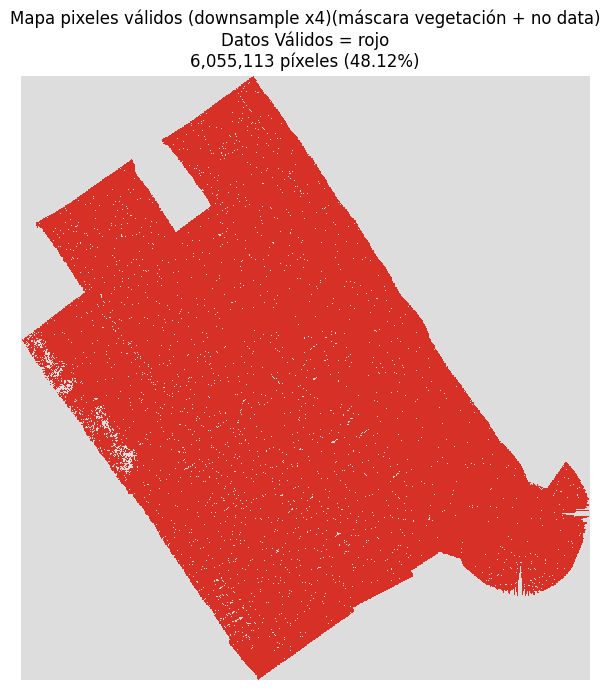

In [18]:
# --- Mapa visual de píxeles NoData (y superposición opcional de veg_mask) ---


# 2) Estadísticos rápidos
total_px = valid_mask.sizes["y"] * valid_mask.sizes["x"]
nodata_px = int(valid_mask.sum().compute())
nodata_pct = 100.0 * nodata_px / total_px
print(f"Pixeles válidos: {nodata_px:,} ({nodata_pct:.2f}%)")

# 3) Preparar una versión reducida para visualización rápida (downsample)
stride = 4
nodata_vis = valid_mask.isel(y=slice(None, None, stride),
                               x=slice(None, None, stride))

# 4) Visualización binaria clara (NoData=1 en rojo, Data=0 en gris claro)
cmap_bin = ListedColormap(["#dddddd", "#d73027"])  # data=gris, NoData=rojo

plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap=cmap_bin, interpolation="nearest")
plt.title(f"Mapa pixeles válidos (downsample x{stride})(máscara vegetación + no data)\nDatos Válidos = rojo\n{nodata_px:,} píxeles ({nodata_pct:.2f}%)")
plt.axis("off")
plt.tight_layout()
# plt.savefig(FIGURES_FOLDER + "/nodata_map_binary.png", dpi=150)
plt.show()

## Etiquetas

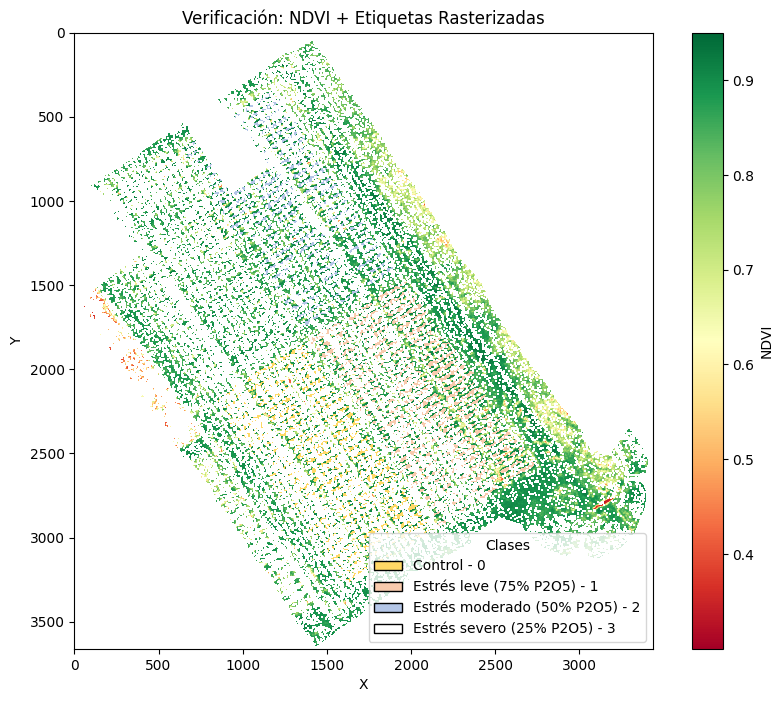

In [19]:
# --- Rutas ---
labels_tiff_path = Path(PathManager().get_abs_path_file("labels_multiclass.tif"))

ndvi = ds["NDVI"].compute()  # Cargar NDVI en memoria para graficar

# --- Obtener transform y CRS ---
crs = ndvi.rio.crs
transform = ndvi.rio.transform()
height, width = ndvi.shape

# Calcular extent para imshow
x_min = transform.c
x_max = transform.c + width * transform.a
y_max = transform.f
y_min = transform.f + height * transform.e  # e es negativo
extent = (x_min, x_max, y_min, y_max)

# --- Abrir GeoTIFF de etiquetas ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)

# --- Graficar overlay ---
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")


# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estrés leve (75% P2O5) - 1",
    2: "Estrés moderado (50% P2O5) - 2",
    3: "Estrés severo (25% P2O5) - 3",
}
colors = ["#FFD966", "#F8CBAD", "#B4C6E7", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

masked_labels = np.ma.masked_where(labels == 255, labels)
ax.imshow(masked_labels, cmap=cmap_labels, alpha=1, extent=extent, origin="upper")

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación: NDVI + Etiquetas Rasterizadas")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.colorbar(img, ax=ax, label="NDVI")
plt.show()

In [20]:
# --- Abrir etiquetas como array ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)  # numpy array (y, x)

# Convertir a binario: 0 = control, resto (1,2,3) = enfermo
labels_bin = np.where(labels == 0, 0, 
                      np.where(
                          np.isin(labels, [1, 2, 3]), 1, np.nan
                        )
                    )

# Aplicar máscara veg-valid
# labels_bin = np.where(valid_mask, labels_bin, np.nan)

In [21]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [22]:
np.isnan(labels_bin).sum().sum()

np.int64(10834441)

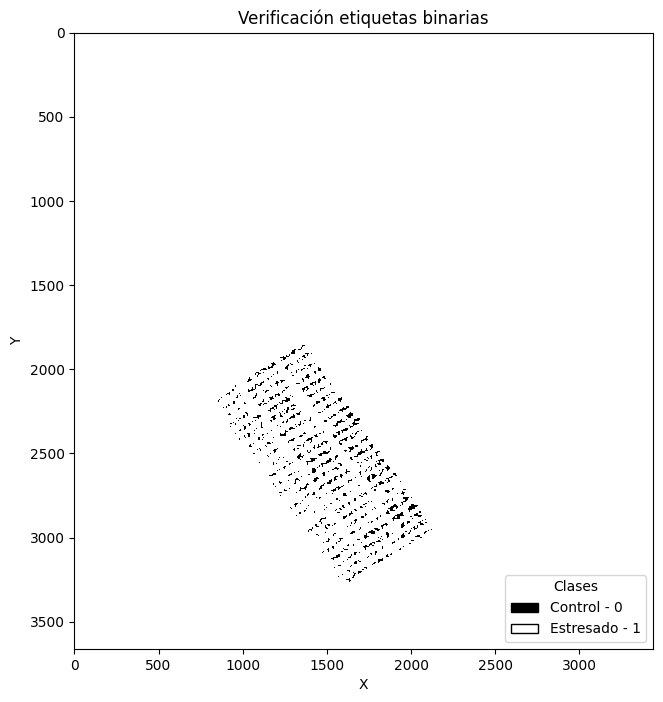

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

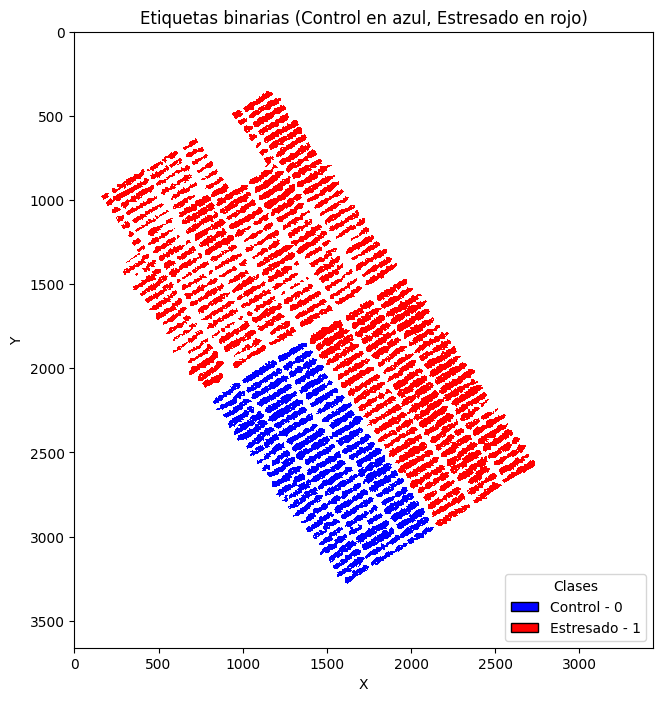

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()


In [25]:
np.isnan(labels_bin).sum()

np.int64(10834441)

In [26]:
labels_bin.shape[0] * labels_bin.shape[1] - np.isnan(labels_bin).sum()

np.int64(1748639)

# 1. Preparación de datos

## 1.1 Preparar matriz de características X

In [27]:
# -----------------------------
# 5. Extraer índices espectrales y bandas clave
# -----------------------------
# Índices ya calculados en Zarr: NDVI, NDRE, CIgreen, PRI, PSRI
indices = ds[["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]]

# Selección de bandas clave por correlación - ver notebook 201-jmmz-select-bands-by-correlation.ipynb
path_selected_bands = PathManager().get_abs_path_file("bands_selected_by_segment.csv")
selected_bands_df = pd.read_csv(path_selected_bands)
selected_bands = selected_bands_df['band_index'].tolist()

reflectance_selected = ds["reflectance"].isel(band=selected_bands)
reflectance_selected

<xarray.DataArray 'reflectance' (band: 58, y: 3660, x: 3438)> Size: 3GB
dask.array<getitem, shape=(58, 3660, 3438), dtype=float32, chunksize=(58, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 232B 1 13 31 41 48 55 67 ... 348 350 352 355 362 374
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']

In [28]:
indices_da = indices.to_array(dim="band")
indices_da

<xarray.DataArray (band: 5, y: 3660, x: 3438)> Size: 252MB
dask.array<stack, shape=(5, 3660, 3438), dtype=float32, chunksize=(1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 40B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI'
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [29]:
nan_counts = indices_da.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)

[6527967 6528031 7596119 7071551 6575062]


In [30]:
# "NDVI", "NDRE", "CIgreen", "PRI", "PSRI"
(~indices_da.isnull()).sum(dim=["y", "x"]).values

# -> CIgreen tiene más NaN que el resto

array([6055113, 6055049, 4986961, 5511529, 6008018])

In [31]:
# -----------------------------
# 6. Construir DataFrame para ML
# -----------------------------
# Aplanar datos válidos
features_stack = xr.concat([indices_da, reflectance_selected], dim="band")
features_stack = features_stack.transpose("y", "x", "band")
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<transpose, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [32]:
nan_counts = features_stack.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)


[6527967 6528031 7596119 7071551 6575062 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411795 6411976 6411921 6412079 6412215 6411748
 6411746 6411768 6411798 6411680 6411663 6411652 6411664 6411678 6411680
 6411708 6411701 6411753 6411742 6411805 6412085 6411960 6412297 6411998]


In [33]:

print("Size features:", features_stack.sizes)
print("Size labels:", labels_bin.shape)


Size features: Frozen({'y': 3660, 'x': 3438, 'band': 63})
Size labels: (3660, 3438)


In [34]:
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<transpose, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [35]:
labels_bin.shape[0]*labels_bin.shape[1]

12583080

In [36]:
# Máscara para extraer solo píxeles válidos
valid_pixels = valid_mask #& ~np.isnan(labels_bin)
valid_pixels.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [37]:
# Extraer valores
X = features_stack.where(valid_pixels)#.values.reshape(-1, features_stack.shape[-1])
X

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<where, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [38]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = ds['reflectance'].isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6484992 (51.54%)


In [39]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = reflectance_selected.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6416232 (50.99%)


In [40]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = indices_da.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


In [41]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = features_stack.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100



print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")
print(f"Píxeles válidos: {features_stack.shape[0]*features_stack.shape[1] - count_nan_pixels}")

Píxeles con ≥1 NaN: 7596119 (60.37%)
Píxeles válidos: 4986961


In [42]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = X.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


Voy a enmascarar los labels para que coincidan con X

In [43]:
X.isnull().any(dim="band").values

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(3660, 3438))

In [44]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [45]:

# Enmascarar: donde mask_nan_pixels == True -> NaN
labels_bin_masked = np.where(X.isnull().any(dim="band").values, np.nan, labels_bin)
labels_bin_masked

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

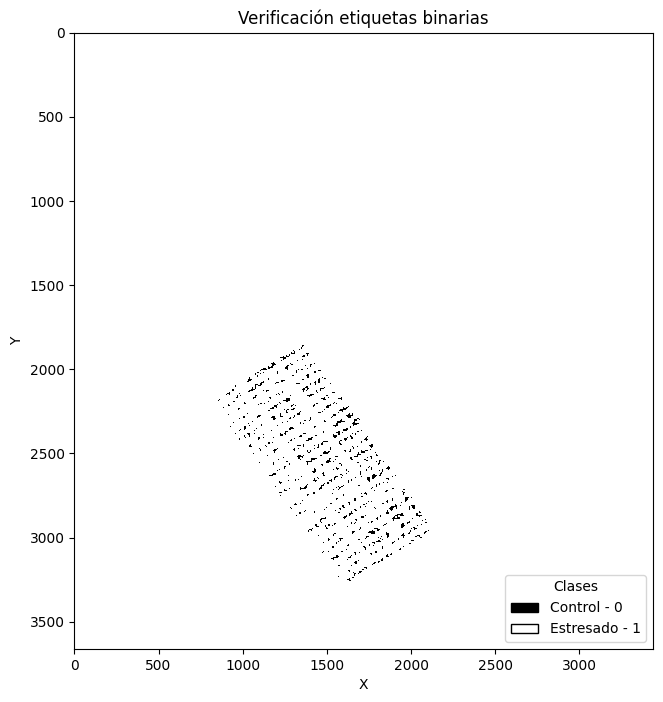

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin_masked, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()


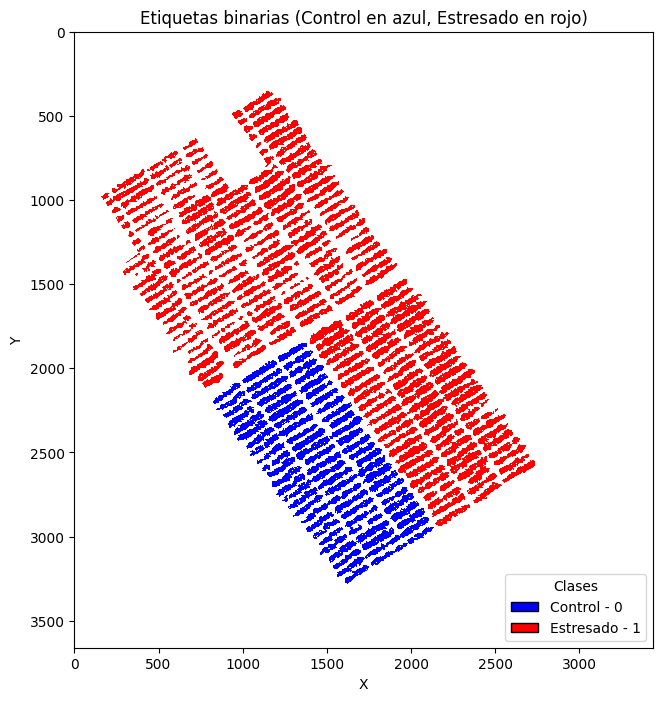

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin_masked, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

In [48]:
np.isnan(labels_bin_masked).sum()

np.int64(10868816)

In [49]:
labels_bin_masked.shape[0] * labels_bin_masked.shape[1] - np.isnan(labels_bin_masked).sum()

np.int64(1714264)

Hay 1714264 labels que tienen todos los features válidos y  además tienen etiqueta válida (0 o 1).

In [50]:
X2 = X.values.reshape(-1, features_stack.shape[-1])
X2

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(12583080, 63), dtype=float32)

In [51]:
labels_bin.reshape(-1)

array([nan, nan, nan, ..., nan, nan, nan], shape=(12583080,))

In [52]:
## Cargar el split espacial del notebook 302-jmmz-spatial-split.ipynb
OUT_SPLIT_TIFF = PathManager().get_abs_path_folder('processed') + "/splits/by_plot_split_id_binary.tif"

with rasterio.open(OUT_SPLIT_TIFF) as src:
    split_id = src.read(1)


split_id

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3660, 3438), dtype=uint8)

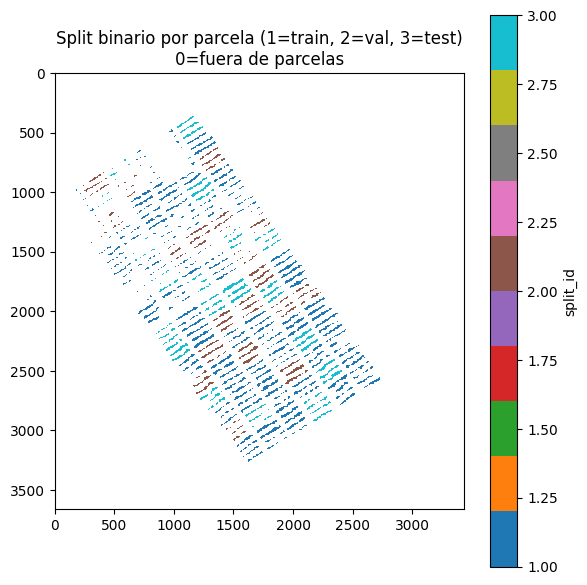

Conteo de píxeles por split: {np.uint8(1): np.int64(1038541), np.uint8(2): np.int64(353211), np.uint8(3): np.int64(372966)}


In [53]:
plt.figure(figsize=(6,6))
plt.imshow(np.where(split_id==0, np.nan, split_id), cmap="tab10", vmin=1, vmax=3)
plt.title("Split binario por parcela (1=train, 2=val, 3=test)\n0=fuera de parcelas")
plt.colorbar(label="split_id")
plt.tight_layout()
plt.show()

# Conteo de píxeles por split dentro de parcelas
vals, counts = np.unique(split_id[split_id>0], return_counts=True)
print("Conteo de píxeles por split:", dict(zip(vals, counts)))

In [54]:
np.unique(np.where(split_id==0, np.nan, split_id).reshape(-1, 1))

array([ 1.,  2.,  3., nan])

In [55]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [56]:
data = np.concatenate([X2, 
                       labels_bin.reshape(-1, 1),
                     #   split_id.reshape(-1, 1),
                       np.where(split_id==0, np.nan, split_id).reshape(-1, 1),
                       ], axis=1)
data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(12583080, 65))

In [57]:
X2[0]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
      dtype=float32)

In [58]:
pd.DataFrame(data).head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
pd.DataFrame(X2).shape[0] - pd.DataFrame(X2).isna().sum()

# La columna que corresponde a CIgreen tiene más NaN que el resto

0     6055113
1     6055049
2     4986961
3     5511529
4     6008018
       ...   
58    6055113
59    6055113
60    6055113
61    6055113
62    6055113
Length: 63, dtype: int64

In [60]:
pd.DataFrame(X2).dropna(axis=0, how='any')

# CIgreen tiene más NaN que el resto, por tanto controla el shape final de X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
18591,0.876371,0.388399,6.273077,-0.033175,0.004831,6.700000e-07,4.700000e-07,6.000000e-07,0.000002,0.000003,...,1.030000e-06,9.200000e-07,6.900000e-07,5.600000e-07,6.600000e-07,9.400000e-07,8.200000e-07,8.700000e-07,8.900000e-07,2.300000e-06
18592,0.880613,0.424105,7.569306,-0.042424,0.003342,5.900000e-07,4.100000e-07,4.900000e-07,0.000002,0.000002,...,7.300000e-07,6.800000e-07,8.400000e-07,8.000001e-07,7.700000e-07,7.300000e-07,4.200000e-07,4.700000e-07,8.700000e-07,3.520000e-06
22027,0.888262,0.451585,8.156757,-0.039216,0.002761,4.400000e-07,3.100000e-07,4.200000e-07,0.000001,0.000002,...,7.200000e-07,7.800000e-07,1.030000e-06,1.140000e-06,9.200000e-07,6.000000e-07,2.000000e-07,7.000000e-07,5.300000e-07,1.640000e-06
22028,0.882353,0.408375,6.766949,-0.036082,0.003781,5.900000e-07,3.700000e-07,5.200000e-07,0.000002,0.000002,...,6.300000e-07,6.600000e-07,9.300000e-07,1.000000e-06,9.600001e-07,9.200000e-07,5.800000e-07,8.100000e-07,5.800000e-07,1.180000e-06
22029,0.875403,0.411955,6.768888,-0.040650,0.003309,6.300000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,7.100000e-07,6.400000e-07,5.500000e-07,4.300000e-07,5.100000e-07,7.899999e-07,8.200000e-07,7.700000e-07,6.100000e-07,6.900000e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12567322,0.878031,0.306926,4.498925,-0.011704,-0.002907,8.600001e-07,9.200000e-07,1.160000e-06,0.000004,0.000005,...,9.400000e-07,1.080000e-06,1.200000e-06,1.260000e-06,1.560000e-06,1.480000e-06,1.170000e-06,1.280000e-06,8.900000e-07,9.800000e-07
12567323,0.881054,0.312920,4.516737,-0.011613,-0.000798,7.600000e-07,9.800000e-07,1.180000e-06,0.000004,0.000005,...,1.490000e-06,1.330000e-06,1.120000e-06,1.140000e-06,1.480000e-06,1.680000e-06,1.280000e-06,9.300000e-07,9.400000e-07,1.050000e-06
12567324,0.883433,0.338011,4.973154,-0.005571,-0.002783,8.400000e-07,9.800000e-07,1.180000e-06,0.000004,0.000004,...,1.690000e-06,1.360000e-06,1.280000e-06,1.160000e-06,1.310000e-06,1.100000e-06,8.900000e-07,9.600001e-07,1.260000e-06,1.240000e-06
12570760,0.879377,0.310884,4.751773,-0.004172,-0.000444,9.800000e-07,9.100000e-07,1.030000e-06,0.000004,0.000004,...,1.260000e-06,1.120000e-06,1.120000e-06,1.030000e-06,1.010000e-06,8.800000e-07,9.700000e-07,6.700000e-07,1.060000e-06,7.700000e-07


In [61]:
data_ = pd.DataFrame(data).dropna(axis=0, how='any')
data_.rename(columns={data_.columns[-2]: 'label'}, inplace=True)
data_.rename(columns={data_.columns[-1]: 'split'}, inplace=True)
data_ 

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,label,split
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,0.000002,0.000003,...,1.210000e-06,1.410000e-06,0.000001,0.000001,1.520000e-06,1.080000e-06,1.170000e-06,1.680000e-06,1.0,3.0
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,0.000003,0.000004,...,1.360000e-06,1.320000e-06,0.000001,0.000001,1.440000e-06,1.240000e-06,1.590000e-06,2.570000e-06,1.0,3.0
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,0.000002,0.000002,...,1.480000e-06,1.450000e-06,0.000001,0.000001,1.220000e-06,1.420000e-06,9.300000e-07,2.120000e-06,1.0,3.0
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,0.000003,0.000004,...,1.200000e-06,1.120000e-06,0.000001,0.000001,1.200000e-06,1.210000e-06,1.060000e-06,2.730000e-06,1.0,3.0
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,0.000003,0.000004,...,1.070000e-06,1.190000e-06,0.000001,0.000001,1.160000e-06,7.899999e-07,1.460000e-06,2.730000e-06,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.000000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,1.020000e-06,1.350000e-06,0.000002,0.000001,1.430000e-06,9.900000e-07,1.470000e-06,1.700000e-06,0.0,1.0
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,4.900000e-07,2.500000e-07,3.300000e-07,0.000001,0.000001,...,1.380000e-06,1.600000e-06,0.000002,0.000001,8.600001e-07,5.700000e-07,9.500000e-07,2.020000e-06,0.0,1.0
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,7.899999e-07,7.200000e-07,8.400000e-07,0.000002,0.000003,...,1.160000e-06,9.700000e-07,0.000001,0.000001,9.500000e-07,1.200000e-06,1.250000e-06,1.180000e-06,0.0,1.0
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,7.800000e-07,9.500000e-07,1.080000e-06,0.000003,0.000003,...,1.310000e-06,8.100000e-07,0.000001,0.000001,1.030000e-06,1.530000e-06,5.200000e-07,8.300000e-07,0.0,1.0


In [62]:
resumen_df = data_.groupby(["label", "split"]).size().unstack(fill_value=0).rename(
    columns={1: 'train', 2: 'val', 3: 'test'}
)

resumen_df

split,train,val,test
label,,,
0.0,304220,93238,92596
1.0,704959,250037,269214


In [63]:
resumen_df.div(resumen_df.sum(axis=0), axis=1) * 100

split,train,val,test
label,,,
0.0,30.145296,27.161314,25.592438
1.0,69.854704,72.838686,74.407562


## 1.2 Separar X y y validados

In [64]:
X = data_.drop(columns=["label", "split"])
y = data_.loc[:, "label"]
split = data_.loc[:, "split"]

In [65]:
X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,4.500000e-07,5.400000e-07,6.800000e-07,0.000002,0.000003,...,1.170000e-06,1.260000e-06,1.210000e-06,1.410000e-06,0.000001,0.000001,1.520000e-06,1.080000e-06,1.170000e-06,1.680000e-06
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,6.300000e-07,7.000000e-07,7.800000e-07,0.000003,0.000004,...,1.200000e-06,1.350000e-06,1.360000e-06,1.320000e-06,0.000001,0.000001,1.440000e-06,1.240000e-06,1.590000e-06,2.570000e-06
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.600000e-07,4.800000e-07,4.600000e-07,0.000002,0.000002,...,1.930000e-06,1.870000e-06,1.480000e-06,1.450000e-06,0.000001,0.000001,1.220000e-06,1.420000e-06,9.300000e-07,2.120000e-06
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,6.300000e-07,7.600000e-07,8.300000e-07,0.000003,0.000004,...,1.320000e-06,1.350000e-06,1.200000e-06,1.120000e-06,0.000001,0.000001,1.200000e-06,1.210000e-06,1.060000e-06,2.730000e-06
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,6.500000e-07,8.000001e-07,9.600001e-07,0.000003,0.000004,...,9.200000e-07,1.040000e-06,1.070000e-06,1.190000e-06,0.000001,0.000001,1.160000e-06,7.899999e-07,1.460000e-06,2.730000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.000000e-07,4.300000e-07,5.500000e-07,0.000002,0.000002,...,9.700000e-07,8.600001e-07,1.020000e-06,1.350000e-06,0.000002,0.000001,1.430000e-06,9.900000e-07,1.470000e-06,1.700000e-06
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,4.900000e-07,2.500000e-07,3.300000e-07,0.000001,0.000001,...,1.410000e-06,1.350000e-06,1.380000e-06,1.600000e-06,0.000002,0.000001,8.600001e-07,5.700000e-07,9.500000e-07,2.020000e-06
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,7.899999e-07,7.200000e-07,8.400000e-07,0.000002,0.000003,...,1.250000e-06,1.270000e-06,1.160000e-06,9.700000e-07,0.000001,0.000001,9.500000e-07,1.200000e-06,1.250000e-06,1.180000e-06
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,7.800000e-07,9.500000e-07,1.080000e-06,0.000003,0.000003,...,1.190000e-06,1.480000e-06,1.310000e-06,8.100000e-07,0.000001,0.000001,1.030000e-06,1.530000e-06,5.200000e-07,8.300000e-07


In [66]:
y

1204447     1.0
1204448     1.0
1207884     1.0
1207885     1.0
1207886     1.0
           ... 
11264513    0.0
11264514    0.0
11267949    0.0
11267950    0.0
11267951    0.0
Name: label, Length: 1714264, dtype: float64

In [67]:
split

1204447     3.0
1204448     3.0
1207884     3.0
1207885     3.0
1207886     3.0
           ... 
11264513    1.0
11264514    1.0
11267949    1.0
11267950    1.0
11267951    1.0
Name: split, Length: 1714264, dtype: float64

In [68]:
print(f"Shape X: {X.shape}, Shape y: {y.shape}, shape split: {split.shape}, Clases: {np.unique(y)}, Split IDs: {np.unique(split)}")    

Shape X: (1714264, 63), Shape y: (1714264,), shape split: (1714264,), Clases: [0. 1.], Split IDs: [1. 2. 3.]


In [69]:
pd.Series(y).value_counts()

label
1.0    1224210
0.0     490054
Name: count, dtype: int64

## 1.3 Split de datos en train/test (Aplicando split espacial)

In [70]:
# División train, test, val usando los IDs espaciales cargados

X_train, X_val, X_test, y_train, y_val, y_test = (
    X[split == 1], X[split == 2], X[split == 3],
    y[split == 1], y[split == 2], y[split == 3],
)

In [71]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((1009179, 63), (1009179,), (361810, 63), (361810,), (343275, 63), (343275,))

In [72]:
resumen_df

split,train,val,test
label,,,
0.0,304220,93238,92596
1.0,704959,250037,269214


In [73]:
resumen_df.sum(axis=0)

split
train    1009179
val       343275
test      361810
dtype: int64

## 1.4 Scaler

### Create

In [ ]:
# # -----------------------------
# # 3. Escalado robusto
# # -----------------------------
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# # 2. Scaler
# base_joblib_path = "../models/checkpoints/"
# joblib.dump(scaler, base_joblib_path + "robust_scaler.pkl")

### Load

In [74]:
base_joblib_path = "../models/checkpoints/"
scaler = joblib.load(filename=base_joblib_path + "robust_scaler.pkl")

c:\Users\mario\Documentos\personal_projects\thesis\.venvLazy\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.7.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [75]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [76]:
X_train_scaled

array([[-5.2871528 , -0.64362406, -0.61960271, ..., -1.39999999,
        -0.83018882, -1.04395633],
       [-5.15468601, -0.58615462, -0.51652919, ..., -1.17777779,
        -0.71698126, -1.07692327],
       [-4.86535309, -0.74903358, -0.68467803, ..., -0.57777784,
        -0.54716986, -0.64835184],
       ...,
       [-1.57229569, -0.5235385 , -0.53152692, ...,  0.35555557,
         0.05660383, -0.95604417],
       [-2.28746317, -0.68332758, -0.69579574, ...,  1.0888887 ,
        -1.32075495, -1.34065964],
       [-1.68315149, -0.49355267, -0.44228863, ...,  0.15555542,
        -1.11320778, -1.4945058 ]], shape=(1009179, 63))

In [77]:
X_test_scaled

array([[-1.31786473, -1.13053074, -1.00299263, ...,  0.08888896,
        -0.09433951, -0.40659364],
       [-0.72293183, -1.1663174 , -0.92334689, ...,  0.44444453,
         0.69811374,  0.57142832],
       [-1.90795932, -0.75582272, -0.82368839, ...,  0.84444433,
        -0.54716986,  0.07692277],
       ...,
       [-1.50236409,  0.10928074,  0.77365541, ..., -0.97777776,
        -0.15094334,  0.47252751],
       [-0.3338865 ,  0.10506473,  0.71728979, ..., -1.42222216,
        -0.28301874, -0.04395633],
       [-0.5329734 ,  0.2866558 ,  0.74021197, ..., -0.79999997,
        -0.3018869 , -0.6813189 ]], shape=(361810, 63))

# 2. LazyPredict

Se utiliza para protipado rápido y evaluar algunos algoritmos destacables para el dataset

In [78]:
from lazypredict.Supervised import LazyClassifier
import sklearn
import xgboost
import lightgbm

In [110]:
classifiers = [
                ('AdaBoostClassifier', sklearn.ensemble._weight_boosting.AdaBoostClassifier),
                ('CategoricalNB', sklearn.naive_bayes.CategoricalNB),
                ('DecisionTreeClassifier', sklearn.tree._classes.DecisionTreeClassifier),
                ('DummyClassifier', sklearn.dummy.DummyClassifier),
                #  ('ExtraTreeClassifier', sklearn.tree._classes.ExtraTreeClassifier),
                #  ('ExtraTreesClassifier', sklearn.ensemble._forest.ExtraTreesClassifier),
                ('GaussianNB', sklearn.naive_bayes.GaussianNB),
                ('KNeighborsClassifier', sklearn.neighbors._classification.KNeighborsClassifier),
                ('LogisticRegression', sklearn.linear_model._logistic.LogisticRegression),
                ('Perceptron', sklearn.linear_model._perceptron.Perceptron),
                ('RandomForestClassifier', sklearn.ensemble._forest.RandomForestClassifier),
                ('RidgeClassifier', sklearn.linear_model._ridge.RidgeClassifier),
                ('SGDClassifier', sklearn.linear_model._stochastic_gradient.SGDClassifier),
                ('XGBClassifier', xgboost.sklearn.XGBClassifier),
                ('LGBMClassifier', lightgbm.sklearn.LGBMClassifier)
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 13/13 [11:42<00:00, 54.03s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
GaussianNB,0.53,0.53,0.53,0.56,3.81
DecisionTreeClassifier,0.60,0.51,0.51,0.61,99.25
KNeighborsClassifier,0.66,0.51,0.51,0.64,356.06
AdaBoostClassifier,0.74,0.50,0.50,0.63,220.29
DummyClassifier,0.74,0.50,0.50,0.63,2.67
LogisticRegression,0.71,0.50,0.50,0.64,14.12


In [ ]:
classifiers = [
                ('Perceptron', sklearn.linear_model._perceptron.Perceptron)
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 7/7 [04:51<00:00, 41.66s/it] 


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
Perceptron,0.62,0.52,0.52,0.62,6.91


In [79]:
classifiers = [
                ('XGBClassifier', xgboost.sklearn.XGBClassifier),
                ('LGBMClassifier', lightgbm.sklearn.LGBMClassifier)
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


 50%|█████     | 1/2 [00:10<00:10, 10.44s/it]

[LightGBM] [Info] Number of positive: 704959, number of negative: 304220
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.092270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15301
[LightGBM] [Info] Number of data points in the train set: 1009179, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.698547 -> initscore=0.840389
[LightGBM] [Info] Start training from score 0.840389


100%|██████████| 2/2 [00:21<00:00, 10.75s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.73,0.51,0.51,0.65,10.44
LGBMClassifier,0.74,0.50,0.50,0.64,11.06


In [ ]:
classifiers = [
                ('RandomForestClassifier', sklearn.ensemble._forest.RandomForestClassifier),
                ('RidgeClassifier', sklearn.linear_model._ridge.RidgeClassifier),
                ('SGDClassifier', sklearn.linear_model._stochastic_gradient.SGDClassifier),
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 4/4 [12:48<00:00, 192.15s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,0.74,0.50,0.50,0.64,754.32
RidgeClassifier,0.73,0.50,0.50,0.64,3.93
SGDClassifier,0.74,0.50,0.50,0.63,7.99


In [81]:
classifiers = [
                ('CategoricalNB', sklearn.naive_bayes.CategoricalNB),
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 1/1 [00:02<00:00,  2.11s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,


# 2. Modelado con XGBoost

## 2.1 Modelo sin optimización de hiperparámetros

In [90]:
mlflow.set_experiment("xgboost")

2026/01/07 11:42:39 INFO mlflow.tracking.fluent: Experiment with name 'xgboost' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/525540c52c1b4855953681bde9a954ae', creation_time=1767804157407, experiment_id='3', last_update_time=1767804157407, lifecycle_stage='active', name='xgboost', tags={}>

In [78]:
# 1) Manejo del desbalance: calcular scale_pos_weight SOLO con TRAIN (positiva=1)
n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (train): {scale_pos_weight:.3f} | pos={n_pos:,} | neg={n_neg:,}")

scale_pos_weight (train): 0.432 | pos=704,959 | neg=304,220


### Prueba rápida


--- Reporte de clasificación ---
              precision    recall  f1-score   support

         0.0      0.311     0.594     0.408     92596
         1.0      0.797     0.546     0.648    269214

    accuracy                          0.559    361810
   macro avg      0.554     0.570     0.528    361810
weighted avg      0.672     0.559     0.587    361810

ROC-AUC: 0.599

Matriz de confusión:
[[ 55035  37561]
 [122133 147081]]


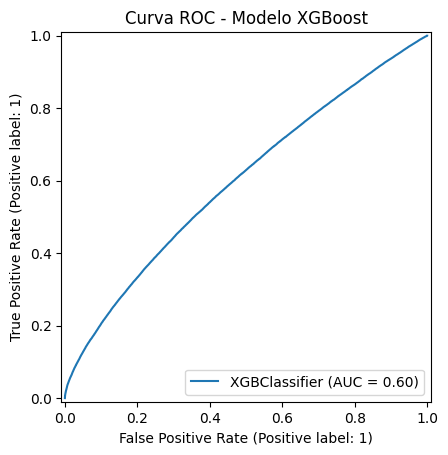

In [83]:
# -----------------------------
# 4. Modelo XGBoost
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train_scaled, y_train)

# -----------------------------
# 5. Predicciones y métricas
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de clasificación ---")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 6. Curva ROC
# -----------------------------
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Curva ROC - Modelo XGBoost")
plt.show()


--- Reporte de clasificación ---
              precision    recall  f1-score   support

         0.0      0.311     0.594     0.408     92596
         1.0      0.797     0.546     0.648    269214

    accuracy                          0.559    361810
   macro avg      0.554     0.570     0.528    361810
weighted avg      0.672     0.559     0.587    361810

ROC-AUC: 0.599

Matriz de confusión:
[[ 55035  37561]
 [122133 147081]]


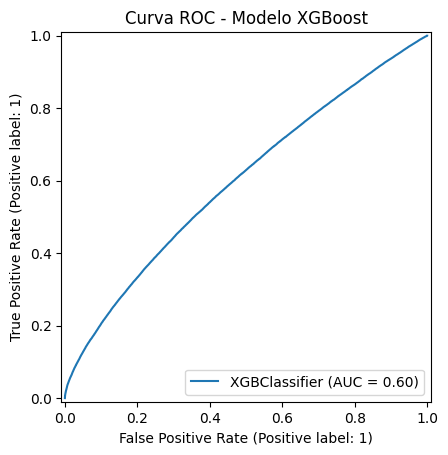

In [84]:
# -----------------------------
# 4. Modelo XGBoost
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='aucpr'

)

model.fit(X_train_scaled, y_train)

# -----------------------------
# 5. Predicciones y métricas
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de clasificación ---")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 6. Curva ROC
# -----------------------------
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Curva ROC - Modelo XGBoost")
plt.show()

### Early stopping y mejor threshold

xgboost version: 3.1.2
scale_pos_weight (train): 0.432 | pos=704,959 | neg=304,220
[0]	train-aucpr:0.74986	val-aucpr:0.76372
[50]	train-aucpr:0.78899	val-aucpr:0.78974
[100]	train-aucpr:0.79943	val-aucpr:0.79373
[150]	train-aucpr:0.80789	val-aucpr:0.79662
[200]	train-aucpr:0.81417	val-aucpr:0.79906
[250]	train-aucpr:0.81923	val-aucpr:0.80056
[300]	train-aucpr:0.82342	val-aucpr:0.80200
[350]	train-aucpr:0.82729	val-aucpr:0.80319
[400]	train-aucpr:0.83059	val-aucpr:0.80447
[450]	train-aucpr:0.83384	val-aucpr:0.80549
[500]	train-aucpr:0.83667	val-aucpr:0.80639
[550]	train-aucpr:0.83908	val-aucpr:0.80726
[600]	train-aucpr:0.84142	val-aucpr:0.80800
[650]	train-aucpr:0.84337	val-aucpr:0.80865
[700]	train-aucpr:0.84551	val-aucpr:0.80956
[750]	train-aucpr:0.84744	val-aucpr:0.81016
[800]	train-aucpr:0.84935	val-aucpr:0.81086
[850]	train-aucpr:0.85101	val-aucpr:0.81122
[900]	train-aucpr:0.85260	val-aucpr:0.81159
[950]	train-aucpr:0.85420	val-aucpr:0.81203
[1000]	train-aucpr:0.85562	val-aucpr:0.8

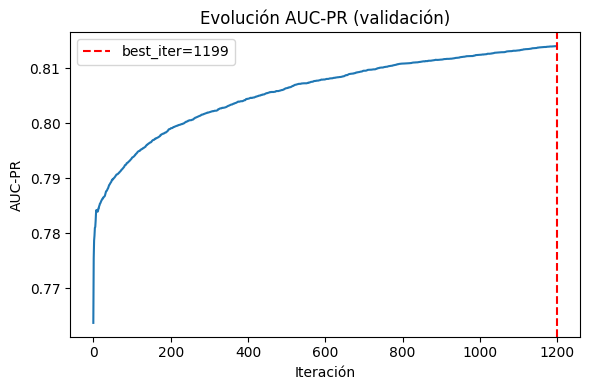

In [130]:
# 1) Manejo del desbalance: calcular scale_pos_weight SOLO con TRAIN (positiva=1)
n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))
scale_pos_weight = n_neg / n_pos
print(f"xgboost version: {xgb.__version__}")
print(f"scale_pos_weight (train): {scale_pos_weight:.3f} | pos={n_pos:,} | neg={n_neg:,}")

# 2) Construir DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# 3) Parámetros (objetivo binario + AUC-PR + desbalance)
params = {
    "objective": "binary:logistic",
    "max_depth": 6,
    "eta": 0.03,                   # learning_rate (más bajo para early stopping fino)
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "aucpr",        # métrica de validación (mejor en desbalance)
    "scale_pos_weight": scale_pos_weight,
    "max_delta_step": 1,           # estabiliza actualización con desbalance
    "tree_method": "hist",
    "nthread": -1,
    "seed": 42
}

# 4) Entrenar con early stopping
evallist = [(dtrain, "train"), (dval, "val")]
evals_result = {}
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1200,          # máximo de árboles; early stopping escogerá menos si conviene
    evals=evallist,
    early_stopping_rounds=100,
    verbose_eval=50,
    evals_result=evals_result
)

val_aucpr = evals_result['val']['aucpr']
plt.figure(figsize=(6,4))
plt.plot(val_aucpr)
plt.axvline(bst.best_iteration, color='r', linestyle='--', 
            label=f'best_iter={bst.best_iteration}')
plt.title('Evolución AUC-PR (validación)')
plt.xlabel('Iteración')
plt.ylabel('AUC-PR')
plt.legend()
plt.tight_layout()
plt.show()

In [131]:

print(f"best_iteration: {bst.best_iteration} | best_aucpr(val): {bst.best_score:.4f}")

best_iteration: 1199 | best_aucpr(val): 0.8140


Umbral óptimo VAL: 0.450 | F1_macro=0.573

--- Reporte de clasificación (TEST) ---
              precision    recall  f1-score   support

         0.0      0.327     0.409     0.364     92596
         1.0      0.778     0.711     0.743    269214

    accuracy                          0.634    361810
   macro avg      0.553     0.560     0.553    361810
weighted avg      0.662     0.634     0.646    361810

ROC-AUC (test): 0.6018318284049798
PR-AUC  (test): 0.8161453633329118

Matriz de confusión (TEST):
[[ 37896  54700]
 [ 77846 191368]]


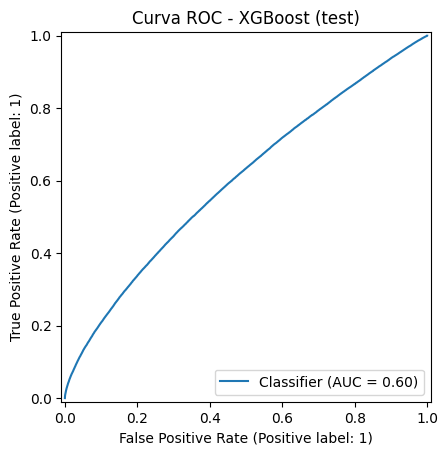

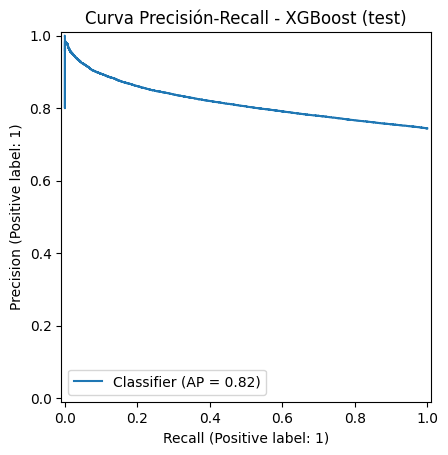

In [132]:
# 5) Probabilidades usando iteration_range
best_iter = getattr(bst, "best_iteration", None)
if best_iter is not None:
    y_prob_val  = bst.predict(dval,  iteration_range=(0, best_iter + 1))
    y_prob_test = bst.predict(dtest, iteration_range=(0, best_iter + 1))
else:
    y_prob_val  = bst.predict(dval)
    y_prob_test = bst.predict(dtest)

# 6) Umbral óptimo en VAL (F1 macro)
thr_grid = np.linspace(0.10, 0.90, 161)
best_thr, best_f1 = max(
    ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro")) for t in thr_grid),
    key=lambda x: x[1]
)
print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

# 7) Métricas en TEST
y_pred_test = (y_prob_test >= best_thr).astype(int)
print("\n--- Reporte de clasificación (TEST) ---")
print(classification_report(y_test, y_pred_test, digits=3))
print("ROC-AUC (test):", roc_auc_score(y_test, y_prob_test))
print("PR-AUC  (test):", average_precision_score(y_test, y_prob_test))
print("\nMatriz de confusión (TEST):")
print(confusion_matrix(y_test, y_pred_test))

# 8) Curvas ROC y PR (TEST)
RocCurveDisplay.from_predictions(y_test, y_prob_test)
plt.title("Curva ROC - XGBoost (test)"); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
plt.title("Curva Precisión-Recall - XGBoost (test)"); plt.show()

In [240]:
def train_xgboost_pipeline(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        run_name="xgboost_with_scaler",
        xgboost_params = None
    ):

    figs_path = PathManager().get_abs_path_folder('figures')
    models_path = PathManager().get_abs_path_folder('models')
    if isinstance(models_path, list):
        models_path = [p for p in models_path if "spectralcrop" not in p][0]

    # -----------------------------
    # scale_pos_weight
    # -----------------------------
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / n_pos

    # -----------------------------
    # Pipeline = scaler + modelo
    # -----------------------------

    if xgboost_params is None:
        xgboost_params = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "scale_pos_weight": scale_pos_weight,
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 500,
            "n_jobs": -1,
            "early_stopping_rounds": 100,
            "random_state": 42,
            "verbosity": 3
        }
    else:
        xgboost_params.setdefault('scale_pos_weight', scale_pos_weight)

    model = Pipeline(steps=[
        ("scaler", RobustScaler()),
        ("xgb", XGBClassifier(
            **xgboost_params
        ))
    ])


    # ===================================================
    # MLflow
    # ===================================================
    with mlflow.start_run(run_name=run_name):
        
        mlflow.log_params(xgboost_params)
        mlflow.log_param("uses_pipeline_scaler", True)

        # -----------------------------
        # FIT (train + val early stopping)
        # -----------------------------


        # # Es importante hacer notar que en esta forma los conjuntos de validación no están siendo escalados
        # # internamente por el wrapper de sklearn, por lo cual se procesde a hacerlo manualmente
        # # Otra opción es unar la API nativa con xgb.train
        # model.fit(
        #         X_train,
        #         y_train,
        #         xgb__eval_set=[(X_val, y_val)],
        #         xgb__verbose=True
        #     )


        # AJUSTE MANUAL DE LOS DATASETS
        # Ajusta scaler primero
        model.named_steps["scaler"].fit(X_train)

        X_train_s = model.named_steps["scaler"].transform(X_train)
        X_val_s   = model.named_steps["scaler"].transform(X_val)

        model.named_steps["xgb"].fit(
            X_train_s, y_train,
            eval_set=[(X_val_s, y_val)],
            verbose=True
        )

        # ============================
        # Evolución AUC-PR
        # ============================

        results = model.named_steps["xgb"].evals_result()
        aucpr_curve = results["validation_0"]["aucpr"]

        plt.figure(figsize=(6,4))
        plt.plot(aucpr_curve)
        plt.axvline(model.named_steps["xgb"].best_iteration, color='r', linestyle='--', 
                    label=f'best_iter={model.named_steps["xgb"].best_iteration}')
        plt.title('Evolución AUC-PR (validación)')
        plt.xlabel('Iteración')
        plt.ylabel('AUC-PR')
        plt.legend()
        plt.tight_layout()
        
        artifact_name = f"evolution_pr_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)


        # -----------------------------
        # Probabilities
        # -----------------------------
        y_prob_val = model.predict_proba(X_val)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]

        # -----------------------------
        # Threshold tuning
        # -----------------------------
        thr_grid = np.linspace(0.01, 0.99, 199)

        best_thr, best_f1 = max(
                ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro")) for t in thr_grid),
                key=lambda x: x[1]
            )

        # 6) Umbral óptimo en VAL (F1 macro)
        thr_grid = np.linspace(0.10, 0.90, 161)
        best_thr, best_f1 = max(
            ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro")) for t in thr_grid),
            key=lambda x: x[1]
        )
        print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

        mlflow.log_metric("best_threshold", best_thr)
        mlflow.log_metric("val_best_f1_macro", best_f1)

        # -----------------------------
        # TEST
        # -----------------------------
        y_pred_test = (y_prob_test >= best_thr).astype(int)

        test_metrics = {
            "test_pr_auc": average_precision_score(y_test, y_prob_test),
            "test_roc_auc": roc_auc_score(y_test, y_prob_test),
            "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
            "test_precision": precision_score(y_test, y_pred_test),
            "test_recall": recall_score(y_test, y_pred_test),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
        }

        mlflow.log_metrics(test_metrics)

        # ============================
        # Confusion Matrix
        # ============================
        cm = confusion_matrix(y_test, y_pred_test)

        print(cm)

        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion matrix (test)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j],
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()

        artifact_name = f"confusion_matrix_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # ============================
        # ROC & PR curves
        # ============================
        RocCurveDisplay.from_predictions(y_test, y_prob_test)
        plt.title("ROC curve (test)")
        artifact_name = f"roc_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
        plt.title("PR curve (test)")
        artifact_name = f"pr_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # # -----------------------------
        # # Save FULL pipeline (model + scaler)
        # # -----------------------------
        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name="bean_stress_classifier"
        )

    return model, test_metrics, best_thr


[0]	validation_0-aucpr:0.76372
[1]	validation_0-aucpr:0.77546
[2]	validation_0-aucpr:0.77869
[3]	validation_0-aucpr:0.77958
[4]	validation_0-aucpr:0.78099
[5]	validation_0-aucpr:0.78116
[6]	validation_0-aucpr:0.78229
[7]	validation_0-aucpr:0.78376
[8]	validation_0-aucpr:0.78425
[9]	validation_0-aucpr:0.78404
[10]	validation_0-aucpr:0.78399
[11]	validation_0-aucpr:0.78394
[12]	validation_0-aucpr:0.78402
[13]	validation_0-aucpr:0.78452
[14]	validation_0-aucpr:0.78454
[15]	validation_0-aucpr:0.78493
[16]	validation_0-aucpr:0.78509
[17]	validation_0-aucpr:0.78539
[18]	validation_0-aucpr:0.78545
[19]	validation_0-aucpr:0.78564
[20]	validation_0-aucpr:0.78584
[21]	validation_0-aucpr:0.78597
[22]	validation_0-aucpr:0.78608
[23]	validation_0-aucpr:0.78623
[24]	validation_0-aucpr:0.78625
[25]	validation_0-aucpr:0.78646
[26]	validation_0-aucpr:0.78648
[27]	validation_0-aucpr:0.78660
[28]	validation_0-aucpr:0.78667
[29]	validation_0-aucpr:0.78672
[30]	validation_0-aucpr:0.78685
[31]	validation_0-

Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/07 16:51:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 22
Created version '22' of model 'bean_stress_classifier'.


🏃 View run xgboost_baseline at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/d0722931971748018a021281f851f06d
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3


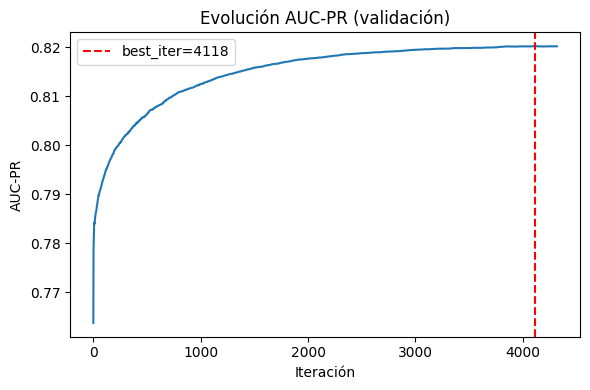

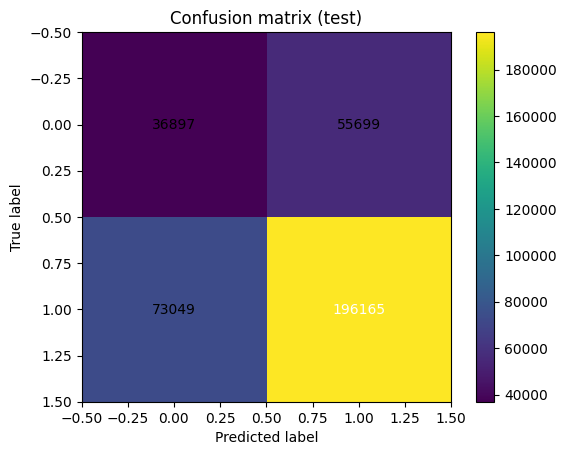

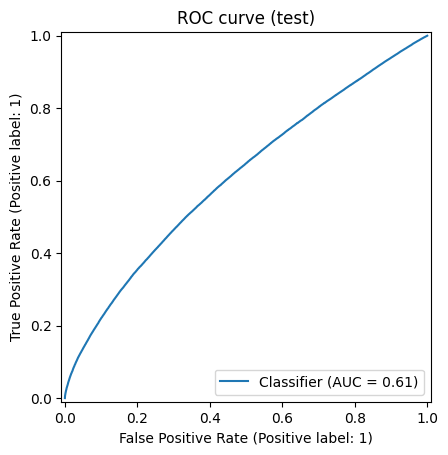

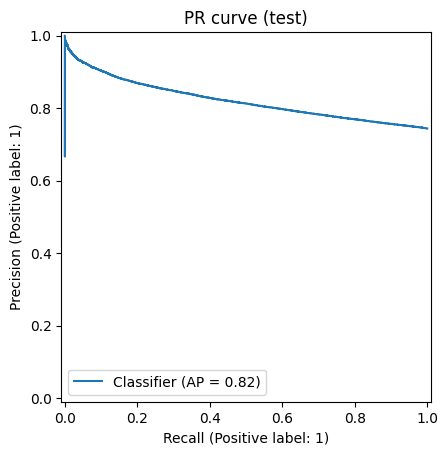

In [241]:
xgboost_params = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 5500,
            "n_jobs": -1,
            "early_stopping_rounds": 200,
            "random_state": 42,
            "verbosity": 3
        }

model, test_metrics, best_thr = train_xgboost_pipeline(
    X_train = X_train.values, y_train=y_train.values,
    X_val = X_val.values, y_val=y_val.values,
    X_test = X_test.values, y_test=y_test.values,
    run_name="xgboost_baseline",
    xgboost_params=xgboost_params
)

In [ ]:
# Sweep de umbral con criterios alternativos
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve

def sweep_thresholds(y_true, y_prob, metric="balanced_accuracy"):
    thr_grid = np.linspace(0.05, 0.95, 181)
    rows = []
    for t in thr_grid:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rec0 = tn / (tn + fp + 1e-9)
        rec1 = tp / (tp + fn + 1e-9)
        ba = 0.5*(rec0 + rec1)
        rows.append({"thr": t, "rec0": rec0, "rec1": rec1, "BA": ba, "FPR": fp/(fp+tn+1e-9)})
    return rows

rows = sweep_thresholds(y_val, y_prob_val)
best_ba = max(rows, key=lambda r: r["BA"])
print(f"Mejor BA en VAL -> thr={best_ba['thr']:.3f} | rec0={best_ba['rec0']:.3f} | rec1={best_ba['rec1']:.3f}")


Mejor BA en VAL -> thr=0.500 | rec0=0.611 | rec1=0.565


In [ ]:
# Evaluar TEST con thr=0.50

import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score
)

THR = 0.50  # umbral elegido por mejor BA en validación

y_pred_test_thr = (y_prob_test >= THR).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_thr).ravel()

rec0 = tn / (tn + fp + 1e-9)  # specificity
rec1 = tp / (tp + fn + 1e-9)  # sensitivity/recall
ba   = 0.5 * (rec0 + rec1)

print(f"Evaluación TEST @thr={THR:.3f}")
print(f"recall_0={rec0:.3f} | recall_1={rec1:.3f} | BA={ba:.3f}")
print("\nMatriz de confusión (TEST):")
print(confusion_matrix(y_test, y_pred_test_thr))
print("\nReporte de clasificación (TEST):")
print(classification_report(y_test, y_pred_test_thr, digits=3))

# AUCs (independientes del umbral)
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob_test):.3f}")
print(f"PR-AUC  (test): {average_precision_score(y_test, y_prob_test):.3f}")


Evaluación TEST @thr=0.500
recall_0=0.596 | recall_1=0.549 | BA=0.573

Matriz de confusión (TEST):
[[ 55223  37373]
 [121473 147741]]

Reporte de clasificación (TEST):
              precision    recall  f1-score   support

         0.0      0.313     0.596     0.410     92596
         1.0      0.798     0.549     0.650    269214

    accuracy                          0.561    361810
   macro avg      0.555     0.573     0.530    361810
weighted avg      0.674     0.561     0.589    361810

ROC-AUC (test): 0.602
PR-AUC  (test): 0.816


In [ ]:
from sklearn.metrics import confusion_matrix

def metrics_at(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    rec0 = tn / (tn + fp + 1e-9)
    rec1 = tp / (tp + fn + 1e-9)
    ba   = 0.5 * (rec0 + rec1)
    return {"thr": thr, "rec0": rec0, "rec1": rec1, "BA": ba}

m_0445 = metrics_at(y_test, y_prob_test, 0.445)  # tu umbral anterior
m_0500 = metrics_at(y_test, y_prob_test, 0.500)  # nuevo umbral (BA)
m_0520 = metrics_at(y_test, y_prob_test, 0.520)  # nuevo umbral (BA)
m_0550 = metrics_at(y_test, y_prob_test, 0.550)  # nuevo umbral (BA)
print("TEST @thr=0.445:", m_0445)
print("TEST @thr=0.500:", m_0500)
print("TEST @thr=0.520:", m_0520)
print("TEST @thr=0.550:", m_0550)


TEST @thr=0.445: {'thr': 0.445, 'rec0': np.float64(0.3898440537388182), 'rec1': np.float64(0.725772062374168), 'BA': np.float64(0.5578080580564931)}
TEST @thr=0.500: {'thr': 0.5, 'rec0': np.float64(0.5963864529785239), 'rec1': np.float64(0.548786467271388), 'BA': np.float64(0.572586460124956)}
TEST @thr=0.520: {'thr': 0.52, 'rec0': np.float64(0.6657954987256397), 'rec1': np.float64(0.4823300422712026), 'BA': np.float64(0.5740627704984211)}
TEST @thr=0.550: {'thr': 0.55, 'rec0': np.float64(0.7575597218022294), 'rec1': np.float64(0.3863246339343408), 'BA': np.float64(0.5719421778682852)}


## 2.2 Optimización de hiperparámetros

In [114]:

import xgboost as xgb
import numpy as np
import pandas as pd
import time

# 1) Desbalance SOLO del TRAIN (positiva = 1 estresado)
n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (train): {scale_pos_weight:.3f} | pos={n_pos:,} | neg={n_neg:,}")

# 2) DMatrix para API xgb.train (compatible con xgboost==3.1.2)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)


scale_pos_weight (train): 0.432 | pos=704,959 | neg=304,220


In [116]:

# Random Search de hiperparámetros con early stopping
rng = np.random.default_rng(42)

def sample_params(scale_pos_weight):
    return {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",       # mejor en desbalance
        "tree_method": "hist",        # rápido en CPU
        "seed": 42,
        "nthread": -1,
        # Hiperparámetros a buscar:
        "max_depth": int(rng.integers(5, 9)),                  # 5–8
        "eta": float(rng.uniform(0.03, 0.10)),                  # 0.03–0.10
        "subsample": float(rng.uniform(0.7, 0.9)),              # 0.7–0.9
        "colsample_bytree": float(rng.uniform(0.7, 0.9)),       # 0.7–0.9
        "min_child_weight": float(rng.uniform(2.0, 8.0)),       # 2–8
        "gamma": float(rng.uniform(0.0, 0.5)),                  # 0–0.5
        "reg_lambda": float(rng.uniform(1.0, 6.0)),             # L2
        "reg_alpha": float(rng.uniform(0.0, 0.6)),              # L1
        "max_delta_step": int(rng.integers(0, 3)),              # 0–2
        "scale_pos_weight": float(scale_pos_weight)             # fijado desde TRAIN
    }

def train_one(params, num_boost_round=1200, early_stopping_rounds=100, verbose_eval=False):
    evallist = [(dtrain, "train"), (dval, "val")]
    t0 = time.perf_counter()
    bst = xgb.train(params, dtrain, num_boost_round=num_boost_round,
                    evals=evallist, early_stopping_rounds=early_stopping_rounds,
                    verbose_eval=verbose_eval)
    elapsed = time.perf_counter() - t0
    return {
        "bst": bst,
        "score": bst.best_score,      # mejor aucpr(val)
        "best_iteration": bst.best_iteration,
        "elapsed_s": elapsed,
        "params": params
    }


In [119]:

# Ejecutar búsqueda
n_trials = 30  # ajusta según tiempo disponible
results = []
for i in range(n_trials):
    print(f"\n--- Trial {i+1}/{n_trials} ---")
    p = sample_params(scale_pos_weight)
    out = train_one(p, verbose_eval=50)
    out["trial"] = i
    results.append(out)
    print(f"[{i+1}/{n_trials}] aucpr(val)={out['score']:.4f} | best_iter={out['best_iteration']} | "
          f"eta={p['eta']:.3f} max_depth={p['max_depth']} subsample={p['subsample']:.2f} "
          f"colsample_bytree={p['colsample_bytree']:.2f} min_child_weight={p['min_child_weight']:.2f} "
          f"lambda={p['reg_lambda']:.2f} alpha={p['reg_alpha']:.2f} gamma={p['gamma']:.2f} "
          f"mds={p['max_delta_step']} | time={out['elapsed_s']:.1f}s")

# Tabla de resultados ordenada por aucpr(val)
tbl = pd.DataFrame([{
    "trial": r["trial"],
    "aucpr_val": r["score"],
    "best_iter": r["best_iteration"],
    "elapsed_s": r["elapsed_s"],
    **{k: r["params"][k] for k in [
        "eta","max_depth","subsample","colsample_bytree",
        "min_child_weight","gamma","reg_lambda","reg_alpha","max_delta_step"
    ]}
} for r in results]).sort_values("aucpr_val", ascending=False).reset_index(drop=True)

print("\nTop-10 configuraciones por AUC-PR (VALIDACIÓN):")
display(tbl.head(10))



--- Trial 1/30 ---
[0]	train-aucpr:0.74587	val-aucpr:0.76287
[50]	train-aucpr:0.78385	val-aucpr:0.78744
[100]	train-aucpr:0.79317	val-aucpr:0.79160
[150]	train-aucpr:0.80079	val-aucpr:0.79452
[200]	train-aucpr:0.80648	val-aucpr:0.79692
[250]	train-aucpr:0.81072	val-aucpr:0.79856
[300]	train-aucpr:0.81434	val-aucpr:0.79973
[350]	train-aucpr:0.81744	val-aucpr:0.80117
[400]	train-aucpr:0.82046	val-aucpr:0.80226
[450]	train-aucpr:0.82333	val-aucpr:0.80341
[500]	train-aucpr:0.82579	val-aucpr:0.80431
[550]	train-aucpr:0.82788	val-aucpr:0.80494
[600]	train-aucpr:0.82989	val-aucpr:0.80581
[650]	train-aucpr:0.83184	val-aucpr:0.80657
[700]	train-aucpr:0.83367	val-aucpr:0.80718
[750]	train-aucpr:0.83534	val-aucpr:0.80791
[800]	train-aucpr:0.83691	val-aucpr:0.80843
[850]	train-aucpr:0.83836	val-aucpr:0.80894
[900]	train-aucpr:0.83981	val-aucpr:0.80952
[950]	train-aucpr:0.84110	val-aucpr:0.80993
[1000]	train-aucpr:0.84230	val-aucpr:0.81041
[1050]	train-aucpr:0.84354	val-aucpr:0.81091
[1100]	train-

,trial,aucpr_val,best_iter,elapsed_s,eta,max_depth,subsample,colsample_bytree,min_child_weight,gamma,reg_lambda,reg_alpha,max_delta_step
0,24,0.819402,1191,521.244088,0.065443,8,0.838852,0.816223,3.198654,0.402062,4.577036,0.443390,0
1,8,0.819358,1197,55325.699088,0.058447,8,0.862804,0.733395,2.136272,0.045024,4.611797,0.277126,1
2,6,0.819025,1196,480.330262,0.068751,7,0.811841,0.760790,2.184907,0.218359,2.072923,0.245117,1
3,7,0.818830,1195,517.233285,0.046376,8,0.711661,0.756277,3.761563,0.330958,3.785161,0.470339,2
4,17,0.818731,1199,520.982306,0.068783,7,0.721715,0.834448,3.687403,0.329711,4.634973,0.461188,0
5,18,0.818666,1170,551.331644,0.094121,6,0.746043,0.707483,5.329115,0.185461,5.148949,0.484951,0
6,9,0.818628,1184,505.615070,0.065073,7,0.730462,0.839264,4.676938,0.190511,2.507560,0.378170,0
7,25,0.818617,1192,441.249296,0.038663,8,0.885513,0.779516,3.805692,0.244292,4.314321,0.573374,0
8,11,0.818473,1199,582.821179,0.080182,6,0.789872,0.754448,2.578346,0.451301,3.278881,0.121418,2
9,12,0.818449,1198,654.735402,0.070545,7,0.735355,0.871323,6.551117,0.359731,3.160465,0.376385,0


In [120]:
tbl

,trial,aucpr_val,best_iter,elapsed_s,eta,max_depth,subsample,colsample_bytree,min_child_weight,gamma,reg_lambda,reg_alpha,max_delta_step
0,24,0.819402,1191,521.244088,0.065443,8,0.838852,0.816223,3.198654,0.402062,4.577036,0.443390,0
1,8,0.819358,1197,55325.699088,0.058447,8,0.862804,0.733395,2.136272,0.045024,4.611797,0.277126,1
2,6,0.819025,1196,480.330262,0.068751,7,0.811841,0.760790,2.184907,0.218359,2.072923,0.245117,1
3,7,0.818830,1195,517.233285,0.046376,8,0.711661,0.756277,3.761563,0.330958,3.785161,0.470339,2
4,17,0.818731,1199,520.982306,0.068783,7,0.721715,0.834448,3.687403,0.329711,4.634973,0.461188,0
5,18,0.818666,1170,551.331644,0.094121,6,0.746043,0.707483,5.329115,0.185461,5.148949,0.484951,0
6,9,0.818628,1184,505.615070,0.065073,7,0.730462,0.839264,4.676938,0.190511,2.507560,0.378170,0
7,25,0.818617,1192,441.249296,0.038663,8,0.885513,0.779516,3.805692,0.244292,4.314321,0.573374,0
8,11,0.818473,1199,582.821179,0.080182,6,0.789872,0.754448,2.578346,0.451301,3.278881,0.121418,2
9,12,0.818449,1198,654.735402,0.070545,7,0.735355,0.871323,6.551117,0.359731,3.160465,0.376385,0
